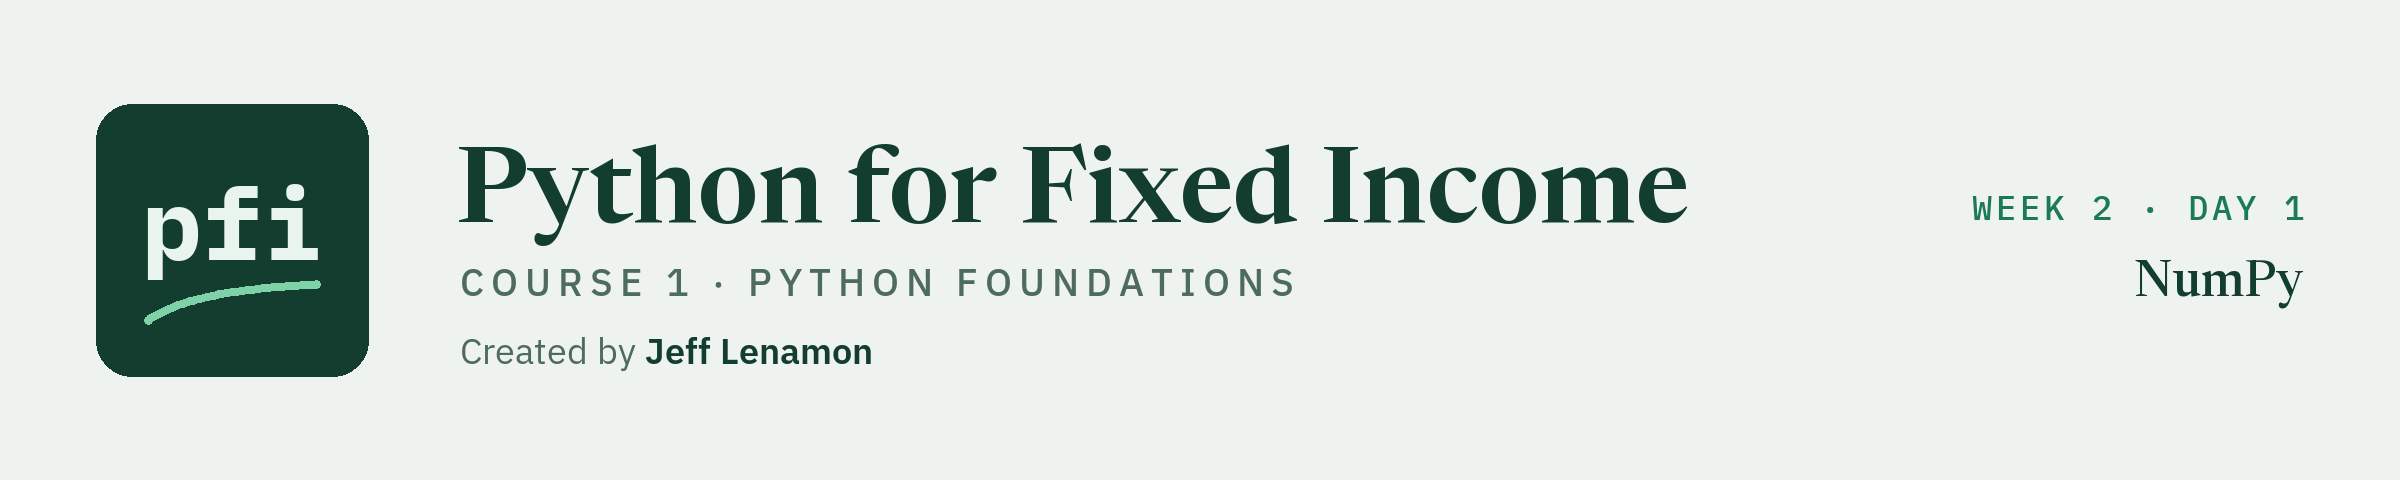

# NumPy

Week 2. Doing arithmetic on a whole column of bonds in one step.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day1/06_numpy.ipynb)

In week 1 the credit desk kept each column of its holdings in a list and worked through it with a loop: one bond at a time, a running total, a few lines of bookkeeping for every question. That is fine for four bonds. The desk's questions are nearly always about the whole column at once: the cost of every position, the yield on every bond, the weighted average of the book.

**NumPy** is the Python library built for that. Its main structure, the **array**, holds a column of numbers and lets us calculate on all of them in a single line. pandas, which we start tomorrow, is built on top of it.

We use the same four bonds as in week 1. The issuers are invented.

| Ticker | Coupon (%) | Maturity | Price | Rating | Score | Face held |
| --- | --- | --- | --- | --- | --- | --- |
| QVNE | 5.25 | 2033 | 98.50 | BBB | 9 | 1,500,000 |
| DNMR | 6.125 | 2034 | 103.25 | BB+ | 11 | 500,000 |
| PLWK | 4.75 | 2031 | 95.00 | A- | 7 | 750,000 |
| HLVF | 7.50 | 2032 | 101.00 | B+ | 14 | 250,000 |

The score is the desk's rating score from week 1: AAA is 1 and each notch lower adds one. A score of 10 or lower is investment grade, and 11 or higher is high yield.

## 6.1 Why Arrays

Let's start with the lists from week 1.

In [1]:
ticker_list = ['QVNE', 'DNMR', 'PLWK', 'HLVF']
coupon_list = [5.25, 6.125, 4.75, 7.5]
price_list = [98.5, 103.25, 95.0, 101.0]
face_list = [1500000, 500000, 750000, 250000]

Q. What did each of the four positions cost? The cost of a position is its face times its price, divided by 100. Can we multiply the two lists?

In [2]:
# try to multiply the face of every bond by its price
face_list * price_list

TypeError: can't multiply sequence by non-int of type 'list'

* A `TypeError`: can't multiply sequence by non-int of type 'list'. A list is a container. It holds numbers, but it does not do arithmetic with them.

The message hints that a list can be multiplied by a whole number. Let's see what that does.

Q. Double every price in the list.

In [3]:
# multiply the list by 2
print(price_list * 2)

[98.5, 103.25, 95.0, 101.0, 98.5, 103.25, 95.0, 101.0]


* No error, and not what we asked for. The list was repeated: eight prices where we had four, and none of them doubled. For a list, `*` means 'repeat'.
* This is the more dangerous of the two results. The first one stopped us. This one ran and handed back something that looks like data.

In week 1 we solved this with a loop.

In [4]:
# start with an empty list, then work out one position at a time
cost_list = []
for face, price in zip(face_list, price_list):
    cost_list.append(face * price / 100)

print(cost_list)

[1477500.0, 516250.0, 712500.0, 252500.0]


* The loop works. It also takes four lines to say 'face times price over 100'.

NumPy lets us say exactly that. NumPy does not come with Python. It was installed along with pandas when you set up the environment from `requirements.txt`. In Google Colab it is already installed.

Q. Import NumPy.

In [5]:
# import the library and give it the short name np
import numpy as np

* `import` loads a library so that its functions can be used. `as np` gives it a short name. Everyone who uses NumPy calls it `np`, so code you find elsewhere will look the same.

Q. Convert the face and price lists to arrays, and work out the cost of every position.

In [6]:
# np.array() converts a list to a NumPy array
faces = np.array(face_list)
prices = np.array(price_list)

# one line of arithmetic covers all four bonds
costs = faces * prices / 100
print(costs)

[1477500.  516250.  712500.  252500.]


* 1,477,500, then 516,250, 712,500, and 252,500: the same four costs the loop produced. The dot after each number is how NumPy prints a number with a decimal point.
* With arrays, `*` means multiply. The first face is multiplied by the first price, the second by the second, and so on down the column.

**Excel side by side.** This is what filling a formula down a column does. With face in column B and price in column C, `=B2*C2/100` filled down four rows gives the same four costs. In Microsoft 365 and Excel 2021, typing `=B2:B5*C2:C5/100` in one cell spills the four costs down the column, which is the closer match to the NumPy line.

## 6.2 Creating Arrays

Q. What is the data type of **prices**, and how does it print?

In [7]:
# check the data type
print(type(prices))
# print the array
print(prices)

<class 'numpy.ndarray'>
[ 98.5  103.25  95.   101.  ]


* The type is `numpy.ndarray`, short for n-dimensional array.
* An array prints with square brackets like a list, but with spaces between the values and no commas. That is the quick way to tell the two apart in an output.

Q. Create arrays for the tickers, the coupons, and the rating scores.

In [8]:
# an array can be made from a list variable or from a list typed in place
tickers = np.array(ticker_list)
coupons = np.array(coupon_list)
scores = np.array([9, 11, 7, 14])

print(tickers)
print(coupons)
print(scores)

['QVNE' 'DNMR' 'PLWK' 'HLVF']
[5.25  6.125 4.75  7.5  ]
[ 9 11  7 14]


* NumPy lines the numbers up to the same width, so 5.25 and 7.5 print with extra spaces. The values are unchanged.

A list can hold a mix of types. An array holds one type only, and that is part of what makes it quick. The type of the values is stored in the attribute `dtype`.

Q. What type of value does each array hold?

In [9]:
# dtype is the type of the values inside the array
print('coupons:', coupons.dtype)
print('faces:', faces.dtype)
print('tickers:', tickers.dtype)

coupons: float64
faces: int64
tickers: <U4


* `float64` is a number with a decimal point and `int64` is a whole number. The 64 is the amount of memory each value uses: 64 bits, which is 8 bytes.
* `<U4` is text of up to 4 characters, the length of our longest ticker.

What happens if a list with mixed types is converted to an array?

In [10]:
# a ticker and its coupon in one list
mixed = np.array(['QVNE', 5.25])
print(mixed)
print(mixed.dtype)

['QVNE' '5.25']
<U32


* There is no error. NumPy made everything text so that the array has one type, and the coupon is now the string '5.25'. No arithmetic can be done on it.
* The rule for this course: one array per column, as in a spreadsheet. Numbers in one array, tickers in another.

Q. How many bonds are in the **prices** array, and how many dimensions does it have?

In [11]:
# size is the number of values
print('Size:', prices.size)
# ndim is the number of dimensions
print('Dimensions:', prices.ndim)
# shape is the length along each dimension
print('Shape:', prices.shape)

Size: 4
Dimensions: 1
Shape: (4,)


* 4 values, in 1 dimension. The array is a single column of data.
* The shape `(4,)` is a tuple with one entry, the length. A table with rows and columns has two entries in its shape. We build one in section 6.5.

Arrays do not have to come from a list. NumPy has functions that build common patterns directly.

Q. A trader wants a run of prices from 95 to 105, one point apart.

In [12]:
# np.arange(start, stop, step) counts from start up to, but not including, stop
price_run = np.arange(95, 106, 1)
print(price_run)

[ 95  96  97  98  99 100 101 102 103 104 105]


* `np.arange()` works like `range()` from week 1 and returns an array. The stop value is left out, so we stop at 106 to get 105 as the last price.

Q. QVNE pays a coupon every six months for the next 7 years. Build the payment times in years: 0.5, 1.0, and so on up to 7.0.

In [13]:
# unlike range(), np.arange() accepts a step with a decimal point
payment_times = np.arange(0.5, 7.5, 0.5)
print(payment_times)
print('Number of payments:', payment_times.size)

[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7. ]
Number of payments: 14


* 14 payment times, from half a year to 7 years. Seven years of semiannual coupons is 14 payments.

Q. Build the same time grid by giving the first time, the last time, and the number of payments.

In [14]:
# np.linspace(start, stop, count) returns count evenly spaced values, including both ends
print(np.linspace(0.5, 7, 14))

[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7. ]


* The same 14 values. Use `np.arange()` when you know the step, and `np.linspace()` when you know how many points you want. `np.linspace()` includes the stop value. `np.arange()` leaves it out when it counts in whole numbers.
* With a decimal step, rounding inside the computer can make `np.arange()` return one value more or one fewer than expected. `np.arange(1, 1.3, 0.1)` ends at 1.3, with the stop value included. The step of 0.5 used here is stored exactly, so this grid is safe. When the step has a decimal point, prefer `np.linspace()`.

Q. The desk wants an empty array to hold the accrued interest of each of the four bonds, to be filled in later.

In [15]:
# np.zeros(n) returns an array of n zeros
accrued = np.zeros(4)
print(accrued)

[0. 0. 0. 0.]


Q. Every bond in the portfolio redeems at 100. Build an array of the four redemption values.

In [16]:
# np.ones(n) returns an array of n ones. Multiply to get any constant.
redemptions = np.ones(4) * 100
print(redemptions)

[100. 100. 100. 100.]


* `np.zeros()` and `np.ones()` create arrays of a given length filled with one value. An array of ones times a number is a quick way to get a constant column, and we use it again in section 6.6 for a bond's coupon payments.

## 6.3 Arithmetic on Whole Arrays

An operation applied to every value of an array at once is called a **vectorized** operation. The cost calculation in section 6.1 was the first one.

Q. Every price in the portfolio rises by half a point. What are the new prices?

In [17]:
# a single number is applied to every value in the array
print(prices + 0.5)

[ 99.   103.75  95.5  101.5 ]


* 99, 103.75, 95.5, and 101.5. One number combined with an array is applied to each value.
* `prices` itself has not changed. The result is a new array, and we only printed it.

Q. How much coupon does each position pay in a year?

In [18]:
# the coupon is in percent, so divide by 100
incomes = faces * coupons / 100
print(incomes)

[78750. 30625. 35625. 18750.]


* 78,750 for QVNE, then 30,625, 35,625, and 18,750. Two arrays of the same length are combined position by position.

Q. What is the current yield of each bond? The current yield is the coupon divided by the price, in percent.

In [19]:
# coupon divided by price, in percent, for all four bonds at once
current_yields = coupons / prices * 100
print(current_yields)

[5.32994924 5.93220339 5.         7.42574257]


* 5.33, 5.93, 5.00, and 7.43 percent, before rounding. PLWK comes out at exactly 5 because 4.75 divided by 95 is exactly 0.05.

Here is the week 1 version of the same calculation, for comparison.

In [20]:
# the loop from week 1: one bond at a time
current_yield_list = []
for coupon, price in zip(coupon_list, price_list):
    current_yield_list.append(coupon / price * 100)

print(current_yield_list)

[5.32994923857868, 5.932203389830509, 5.0, 7.425742574257425]


* The same four numbers. The array version is one line and reads like the formula. The loop still works. The array version is simply less to write and less to get wrong.

Q. What did the whole portfolio cost, and what is its total annual coupon income?

In [21]:
# sum() adds up every value in an array
print('Total cost:', costs.sum())
print('Total annual coupon income:', incomes.sum())

Total cost: 2958750.0
Total annual coupon income: 163750.0


* 2,958,750 and 163,750. Both match the totals from week 1.
* `sum()` here is a method of the array, called with a dot. More of these in the next section.

Arithmetic between two arrays needs them to line up. The desk adds a fifth bond and updates one array but not the other.

In [22]:
# five prices, but faces still has four values
new_prices = np.array([98.5, 103.25, 95.0, 101.0, 99.0])
faces * new_prices / 100

ValueError: operands could not be broadcast together with shapes (4,) (5,) 

* A `ValueError`: operands could not be broadcast together with shapes (4,) (5,). 'Broadcast' is NumPy's word for matching two arrays up. It is telling us one array has 4 values and the other has 5, so there is no way to pair them.
* This error is a friend. A fill-down in Excel with columns of different lengths would quietly leave a blank or a zero. NumPy stops.
* When you see it, print the `shape` of each array in the line that failed.

**Excel side by side.**

| Question | Python | Excel |
| --- | --- | --- |
| Cost of every position | `faces * prices / 100` | `=B2*C2/100` filled down |
| Current yield of every bond | `coupons / prices * 100` | `=D2/C2*100` filled down |
| Total cost | `costs.sum()` | `=SUM(E2:E5)` |
| Total cost with no helper column | `(faces * prices / 100).sum()` | `=SUMPRODUCT(B2:B5, C2:C5)/100` |

## 6.4 Array Functions

NumPy has a function for most of the summary questions a desk asks. Many can be written two ways: as a function, `np.sum(costs)`, or as a method, `costs.sum()`. They give the same answer.

Q. What is the total face held, and what is the average price?

In [23]:
# total face held
print('Total face:', np.sum(faces))
# simple average of the four prices
print('Average price:', np.mean(prices))

Total face: 3000000
Average price: 99.4375


* 3,000,000 of face, and an average price of 99.4375.
* `np.mean()` is the simple average: add the values and divide by the count.

Q. What are the lowest and highest coupons in the portfolio?

In [24]:
print('Lowest coupon:', np.min(coupons))
print('Highest coupon:', np.max(coupons))

Lowest coupon: 4.75
Highest coupon: 7.5


* 4.75 and 7.5. That tells us the values. It does not tell us which bonds they belong to.

Q. Which bond has the highest current yield, and which has the lowest?

In [25]:
# argmax() returns the position of the largest value, not the value itself
highest_position = np.argmax(current_yields)
print('Position of the highest current yield:', highest_position)
# use that position to look up the ticker
print('Highest current yield:', tickers[highest_position])

# argmin() does the same for the smallest value
lowest_position = np.argmin(current_yields)
print('Lowest current yield:', tickers[lowest_position])

Position of the highest current yield: 3
Highest current yield: HLVF
Lowest current yield: PLWK


* The highest current yield is at position 3, which is HLVF. The lowest is PLWK.
* `np.argmax()` and `np.argmin()` return an index. Because every array is in the same bond order, an index found in one array can be used to look up a value in another.

Q. Show the current yields to two decimal places.

In [26]:
# np.round(array, n) rounds every value to n decimal places
print(np.round(current_yields, 2))

[5.33 5.93 5.   7.43]


* 5.33, 5.93, 5, and 7.43. Round at the end, for display. Keep the full values in `current_yields` for any further calculation.

Q. List the coupons from lowest to highest.

In [27]:
# np.sort() returns a sorted copy and leaves the original alone
print('Sorted:', np.sort(coupons))
print('Original:', coupons)

Sorted: [4.75  5.25  6.125 7.5  ]
Original: [5.25  6.125 4.75  7.5  ]


* 4.75, 5.25, 6.125, 7.5. The sorted values no longer line up with `tickers`, so we cannot tell which coupon is whose.

Q. List the tickers in order of coupon, lowest first.

In [28]:
# np.argsort() returns the positions that would sort the array
order = np.argsort(coupons)
print('Order:', order)
# a list of positions inside the brackets picks those items, in that order
print('Tickers by coupon:', tickers[order])
print('Coupons in that order:', coupons[order])

Order: [2 0 1 3]
Tickers by coupon: ['PLWK' 'QVNE' 'DNMR' 'HLVF']
Coupons in that order: [4.75  5.25  6.125 7.5  ]


* The order is 2, 0, 1, 3: PLWK, QVNE, DNMR, HLVF.
* `np.argsort()` is to `np.sort()` what `np.argmax()` is to `np.max()`. It gives positions, and the same positions can reorder every other array to match. This is what sorting a whole table by one column does in Excel.

Q. Going down the portfolio in the order of the table, what is the running total of face held?

In [29]:
# np.cumsum() returns the running total
print(np.cumsum(faces))

[1500000 2000000 2750000 3000000]


* 1,500,000, then 2,000,000, 2,750,000, and 3,000,000. The last value of a running total is always the plain total.

Q. What is the average coupon of the portfolio?

In [30]:
# the simple average: every bond counts the same
simple_average = np.mean(coupons)
print('Simple average coupon:', simple_average)

Simple average coupon: 5.90625


* 5.90625, the same figure as in week 1. Week 1 promised a weighted average later in the course. Here it is.

The simple average treats the 250,000 of HLVF the same as the 1,500,000 of QVNE. A **weighted average** counts each coupon in proportion to the face held.

Q. What is the face-weighted average coupon?

In [31]:
# np.average() takes a weights argument. Each coupon counts in proportion to its face.
weighted_average = np.average(coupons, weights=faces)
print('Face-weighted average coupon:', weighted_average)

Face-weighted average coupon: 5.458333333333333


* About 5.458, against a simple average of 5.90625. The weighted figure is lower because the largest position, QVNE, has one of the lower coupons, and the highest coupon, HLVF, is the smallest position.

Let's confirm it the long way.

In [32]:
# multiply each coupon by its face, add them up, and divide by the total face
by_hand = (coupons * faces).sum() / faces.sum()
print('By hand:', by_hand)

# the same figure from the totals we already have
print('Income over face:', incomes.sum() / faces.sum() * 100)

By hand: 5.458333333333333
Income over face: 5.458333333333333


* All three agree. The last line is the reason the weighted figure is the one that matters for a portfolio: 163,750 of annual coupon on 3,000,000 of face is 5.458 percent. The simple average of 5.90625 does not correspond to any cash the portfolio receives.

**Excel side by side.** With coupons in D2:D5 and face in B2:B5:

| Python | Excel |
| --- | --- |
| `np.sum(faces)` | `=SUM(B2:B5)` |
| `np.mean(coupons)` | `=AVERAGE(D2:D5)` |
| `np.min(coupons)` | `=MIN(D2:D5)` |
| `np.max(coupons)` | `=MAX(D2:D5)` |
| `tickers[np.argmax(coupons)]` | `=INDEX(A2:A5, MATCH(MAX(D2:D5), D2:D5, 0))` |
| `np.round(current_yields, 2)` | `=ROUND(F2, 2)` filled down |
| `np.average(coupons, weights=faces)` | `=SUMPRODUCT(D2:D5, B2:B5)/SUM(B2:B5)` |

#### Comparing numbers with a decimal point

Day 3 of week 1 showed that `0.1 + 0.2` is not exactly `0.3`: a number with a decimal point is stored in binary, and its last digit can be off. The same happens inside an array, and it matters as soon as two results are compared.

Q. The current yield is the coupon divided by the price, times 100. A colleague's sheet multiplies by 100 first and divides by the price second. Are the two sets of yields equal?

In [33]:
# the same formula with the two steps in the other order
colleague_yields = coupons * 100 / prices

# == compares the two arrays one value at a time
print(current_yields == colleague_yields)

# the two HLVF yields, to 15 decimal places
print(f'Divide first:   {current_yields[3]:.15f}')
print(f'Multiply first: {colleague_yields[3]:.15f}')

[ True  True  True False]
Divide first:   7.425742574257425
Multiply first: 7.425742574257426


* True, True, True, False. Three yields match exactly and the fourth, HLVF, does not.
* The two HLVF figures are 7.425742574257425 and 7.425742574257426. They differ in the fifteenth decimal place. Both are 7.43 percent, and neither is wrong.
* `==` asks whether two numbers are identical down to the last stored digit. For numbers with a decimal point that is the wrong question, and here it reports a difference that does not exist on the desk.

Q. Compare the two arrays so that a difference in the last digit is ignored.

In [34]:
# np.isclose() is True where two values agree to within a very small tolerance
print(np.isclose(current_yields, colleague_yields))

# np.allclose() gives one answer for the whole array: True when every pair is close
print(f'All four agree: {np.allclose(current_yields, colleague_yields)}')

[ True  True  True  True]
All four agree: True


* True four times, and one True for the whole array.
* `np.isclose()` is the array version of `math.isclose()` from week 1. With its default settings two numbers count as close when they agree to about 1 part in 100,000. `np.allclose()` reduces the four answers to one.
* The rule for the rest of the course: compare numbers that have a decimal point with `np.isclose()` or `np.allclose()`, never with `==`. Whole numbers and text are stored exactly, so `==` is right for a count, a face amount, or a ticker.

**Excel side by side.** Excel stores numbers in binary as well. The same care in a worksheet is to test the size of the difference, `=ABS(F2-G2)<0.000001`, or to compare rounded values, `=ROUND(F2, 6)=ROUND(G2, 6)`, in place of `=F2=G2`.

## 6.5 Accessing the Entries of an Array

Indexing and slicing are written the same way on an array as on a list. One thing behaves differently, and we come to it after the first slice.

Q. Print the price of the first bond and the ticker of the third bond.

In [35]:
# counting starts at 0
print(prices[0])
# index 2 is the third item
print(tickers[2])

98.5
PLWK


Q. Print the coupons of the first two bonds, and the face of the last bond.

In [36]:
# a slice starts at index 0 and stops before index 2
print(coupons[0:2])
# a negative index counts from the end
print(faces[-1])

[5.25  6.125]
250000


* 5.25 and 6.125 for the slice, and 250,000 for the last face. A slice of an array is itself an array.

Here is the one difference from a list. A slice of a list is a new list. A slice of an array is not a separate copy. It is a window onto the same numbers.

Q. Take the first two prices as a slice and set the first one to 0. What happens to **prices**? Then do the same on a copy of the slice.

In [37]:
# a slice of an array shares its numbers with the original array
first_two = prices[0:2]
# change the first value of the slice
first_two[0] = 0
print('prices after changing the slice:', prices)

# put the real price back
prices[0] = 98.5

# copy() makes a separate array, so this change stays in the copy
first_two_copy = prices[0:2].copy()
first_two_copy[0] = 0
print('prices after changing the copy: ', prices)

prices after changing the slice: [  0.   103.25  95.   101.  ]
prices after changing the copy:  [ 98.5  103.25  95.   101.  ]


* The change to the slice landed on `prices`: the first price became 0. Nothing warned us.
* The change to the copy did not. `prices` still starts with 98.5.
* When you want to change a slice and keep the original as it is, slice and then `.copy()`.

A note on how single values are displayed. When a value is shown as the result of a cell, without `print()`, NumPy shows its type as well.

In [38]:
# the same value, displayed without print()
prices[0]

np.float64(98.5)

* `np.float64(98.5)` is the number 98.5, labelled with its NumPy type. It behaves like any other number. Use `print()` when you want only the value.

The array has four values, at indexes 0 to 3. What happens if we ask for index 4?

In [39]:
print(prices[4])

IndexError: index 4 is out of bounds for axis 0 with size 4

* An `IndexError`: index 4 is out of bounds for axis 0 with size 4. The message gives both the index we asked for and the size of the array. The last valid index is always the size minus one.

The real power of an array is selecting by a condition, not by position.

Q. Which bonds are priced below par?

In [40]:
# a comparison is applied to every value and returns an array of True and False
below_par = prices < 100
print(below_par)

[ True False  True False]


* True, False, True, False. The first and third bonds are below 100.
* An array of True and False values is called a **boolean mask**.

Q. Print the tickers and the prices of the bonds below par.

In [41]:
# a mask inside the brackets keeps the items where the mask is True
print(tickers[below_par])
print(prices[below_par])

['QVNE' 'PLWK']
[98.5 95. ]


* QVNE at 98.5 and PLWK at 95. The mask was made from `prices`, and it works on `tickers` too, because both arrays are in the same bond order.

Q. How many bonds are below par, and how much face do they add up to?

In [42]:
# True counts as 1 and False as 0, so the sum of a mask is a count
print('Bonds below par:', below_par.sum())
print('Face below par:', faces[below_par].sum())

Bonds below par: 2
Face below par: 2250000


* 2 bonds, holding 2,250,000 of face between them.

Q. Which bonds are high yield, and what is their total annual coupon income? High yield is a rating score of 11 or higher.

In [43]:
# the mask can be written directly inside the brackets
print(tickers[scores >= 11])
print('High yield coupon income:', incomes[scores >= 11].sum())

['DNMR' 'HLVF']
High yield coupon income: 49375.0


* DNMR and HLVF, paying 49,375 a year between them.

Q. Which bonds are high yield and priced above 102?

In [44]:
# & means 'and' for masks. Each condition needs its own round brackets.
print(tickers[(scores >= 11) & (prices > 102)])

['DNMR']


* Only DNMR. For masks, use `&` for 'and' and `|` for 'or', with each condition in its own brackets. The words `and` and `or` from week 1 compare single values and do not work on arrays.

Q. Label each bond as 'Premium' or 'Discount'. None of the four is priced at exactly 100.

In [45]:
# np.where(condition, value if True, value if False)
labels = np.where(prices > 100, 'Premium', 'Discount')
print(labels)

['Discount' 'Premium' 'Discount' 'Premium']


* Discount, Premium, Discount, Premium. `np.where()` checks the condition for every bond and picks one of the two values. In week 1 this took a loop with an `if` and an `else`.

**Excel side by side.**

| Question | Python | Excel |
| --- | --- | --- |
| Label each bond | `np.where(prices > 100, 'Premium', 'Discount')` | `=IF(C2>100, "Premium", "Discount")` filled down |
| Count the bonds below par | `(prices < 100).sum()` | `=COUNTIF(C2:C5, "<100")` |
| Face below par | `faces[prices < 100].sum()` | `=SUMIF(C2:C5, "<100", B2:B5)` |
| Tickers below par | `tickers[prices < 100]` | `=FILTER(A2:A5, C2:C5<100)` in current versions of Excel |

A mask can also be used to change values.

Q. The desk wants a what-if: every bond below par is marked up by one point. The real prices must not change.

In [46]:
# copy() makes a separate array, so changes to the what-if leave prices alone
what_if_prices = prices.copy()
# add a point to the bonds below par only
what_if_prices[below_par] = what_if_prices[below_par] + 1

print('What-if:', what_if_prices)
print('Original:', prices)

What-if: [ 99.5  103.25  96.   101.  ]
Original: [ 98.5  103.25  95.   101.  ]


* QVNE moves to 99.5 and PLWK to 96. The other two are untouched, and so is `prices`.
* The `copy()` matters. Writing `what_if_prices = prices` would not make a second array. It would give the same array a second name, and the change would land on the real prices. The same goes for a slice, as we saw above: `prices[0:2].copy()`.

#### A table in one array

So far each array has been one column. An array can also have two dimensions: rows and columns, like a block of cells.

Q. Put the coupon, price, and face of the four bonds in a single array, one row per bond.

In [47]:
# a list of lists becomes a 2-D array. Each inner list is one row.
bond_table = np.array([[5.25, 98.5, 1500000],
                       [6.125, 103.25, 500000],
                       [4.75, 95.0, 750000],
                       [7.5, 101.0, 250000]])
print(bond_table)

[[5.2500e+00 9.8500e+01 1.5000e+06]
 [6.1250e+00 1.0325e+02 5.0000e+05]
 [4.7500e+00 9.5000e+01 7.5000e+05]
 [7.5000e+00 1.0100e+02 2.5000e+05]]


* The numbers are right but hard to read. When an array mixes small and large values, NumPy switches to scientific notation: `1.5e+06` is 1.5 times 10 to the power 6, which is 1,500,000.

Let's turn that off.

In [48]:
# suppress=True tells NumPy to print plain numbers instead of scientific notation
np.set_printoptions(suppress=True)
print(bond_table)

[[      5.25       98.5   1500000.   ]
 [      6.125     103.25   500000.   ]
 [      4.75       95.     750000.   ]
 [      7.5       101.     250000.   ]]


* The setting changes how arrays are displayed for the rest of the notebook. The values stored are not affected.

Q. What is the shape of the table?

In [49]:
print('Dimensions:', bond_table.ndim)
print('Shape:', bond_table.shape)

Dimensions:

 2
Shape: (4, 3)


* 2 dimensions, with a shape of (4, 3): 4 rows and 3 columns. Rows always come first.

Q. Print the row for DNMR, the second bond.

In [50]:
# one index selects a row
print(bond_table[1])

[     6.125    103.25  500000.   ]


Q. Print the price of DNMR.

In [51]:
# two indexes: row first, then column. Price is column 1.
print(bond_table[1, 1])

103.25


Q. Print the price column for all four bonds.

In [52]:
# a colon on its own means 'every row'
print(bond_table[:, 1])

[ 98.5  103.25  95.   101.  ]


* 98.5, 103.25, 95, and 101. The colon selects all rows, and the 1 selects the price column.

Q. Print the coupon and price of the first two bonds.

In [53]:
# rows 0 and 1, columns 0 and 1
print(bond_table[0:2, 0:2])

[[  5.25   98.5  ]
 [  6.125 103.25 ]]


* Slices work on both dimensions at once. The result is a smaller table of 2 rows and 2 columns.

Q. What is the average of each column?

In [54]:
# axis=0 works down the rows and gives one result per column
print(bond_table.mean(axis=0))

[     5.90625     99.4375  750000.     ]


* 5.90625 for the coupon, 99.4375 for the price, and 750,000 for the face. The first two match the averages from section 6.4.
* Without `axis`, `bond_table.mean()` would average all twelve numbers together, coupons and face amounts alike, which means nothing.

The other direction is `axis=1`, which works across the columns and gives one result per row. It only makes sense when the columns hold the same kind of number. Here is a table where they do: the two coupon payments each bond makes in a year. Each is half of the annual income from section 6.3.

In [55]:
# rows are the four bonds, columns are the first and second coupon payment of the year
payments = np.array([[39375.0, 39375.0],
                     [15312.5, 15312.5],
                     [17812.5, 17812.5],
                     [9375.0, 9375.0]])

Q. How much does each bond pay in a year, and how much does the desk receive in each coupon period, the first and the second of each bond's year?

In [56]:
# axis=1 works across the columns: one total per bond
print('Per bond:', payments.sum(axis=1))
# axis=0 works down the rows: one total per coupon period
print('Per coupon period:', payments.sum(axis=0))
# no axis: one total for the whole table
print('Whole table:', payments.sum())

Per bond: [78750. 30625. 35625. 18750.]
Per coupon period: [81875. 81875.]
Whole table: 163750.0


* Per bond: 78,750, 30,625, 35,625, and 18,750, the annual incomes from section 6.3.
* Per coupon period: 81,875 each time. The four bonds pay on different dates, so this is a total per period, not per calendar date. For the whole table: 163,750, the week 1 total.
* A way to remember it: the axis you name is the one that disappears. `axis=0` collapses the rows and leaves one value per column. `axis=1` collapses the columns and leaves one value per row.

**Excel side by side.** `axis=0` is a `=SUM()` at the bottom of each column. `axis=1` is a `=SUM()` at the right-hand end of each row.

## 6.6 Pricing a Bond From Its Cash Flows

Here is a calculation that shows what arrays are for. The price of a bond is the present value of its cash flows: each payment divided by one plus the yield per period, raised to the number of periods until it is paid.

We price QVNE, the 5.25% bond, per 100 of face. To keep the arithmetic clean we make three assumptions and state them plainly:

* **Whole periods.** The bond has exactly 7 years to maturity, which is 14 semiannual coupon periods.
* **Semiannual compounding.** The yield is quoted as an annual rate and half of it applies to each period.
* **Settlement on a coupon date.** No coupon has started to accrue, so there is no accrued interest.

Real bonds settle between coupon dates and need day counts and accrued interest. The full treatment of price and yield belongs to the Bond Math course. This section is a preview of what arrays make easy.

Q. Number the 14 coupon periods.

In [57]:
# the terms of the bond
coupon = 5.25
years = 7
periods_per_year = 2

# period numbers 1 to 14
periods = np.arange(1, years * periods_per_year + 1)
print(periods)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


Q. Build the cash flows per 100 of face: a coupon every period, and the 100 of principal with the last one.

In [58]:
# each semiannual coupon is half of the annual coupon
cash_flows = np.ones(periods.size) * coupon / periods_per_year
# the principal is repaid with the final coupon
cash_flows[-1] = cash_flows[-1] + 100
print(cash_flows)

[  2.625   2.625   2.625   2.625   2.625   2.625   2.625   2.625   2.625
   2.625   2.625   2.625   2.625 102.625]


* Thirteen payments of 2.625 and a final payment of 102.625.
* `np.ones()` from section 6.2 gives the constant coupon, and a negative index changes the last entry only.

Q. The yield is 5.51 percent. Build the discount factor for each period.

In [59]:
# the yield as a decimal, per period
yield_pct = 5.51
yield_per_period = yield_pct / 100 / periods_per_year

# ** raises to a power. One discount factor for each period number.
discount_factors = 1 / (1 + yield_per_period) ** periods
print(np.round(discount_factors, 4))

[0.9732 0.9471 0.9217 0.897  0.8729 0.8495 0.8268 0.8046 0.783  0.762
 0.7416 0.7217 0.7024 0.6835]


* The first discount factor is 0.9732 and the last is 0.6835. A dollar paid in six months is worth about 97 cents today at this yield, and a dollar paid in 7 years about 68 cents.
* `periods` is an array, so the power is taken for all 14 periods at once.

Q. What is each cash flow worth today, and what is the price of the bond?

In [60]:
# present value of each cash flow
present_values = cash_flows * discount_factors
print(np.round(present_values, 4))

# the price is the sum of the present values
qvne_price = present_values.sum()
print('Price of QVNE at a yield of 5.51 percent:', round(qvne_price, 4))

[ 2.5546  2.4861  2.4195  2.3546  2.2915  2.23    2.1702  2.1121  2.0554
  2.0003  1.9467  1.8945  1.8437 70.1474]
Price of QVNE at a yield of 5.51 percent: 98.5067


* The price is 98.5067, or 98.51 to the cent. That is the 98.50 in the desk's table, to within a cent. Under these assumptions, a price of 98.50 and a yield of about 5.51 percent are two ways of saying the same thing.
* The final payment is worth 70.1474 today, so most of the bond's value sits in the last cash flow.
* The whole calculation is three lines of array arithmetic: cash flows, discount factors, and the sum of their product. There is no loop.

Q. Put the calculation in a function, and use it to price the bond at a yield equal to its coupon.

In [61]:
def price_from_yield(coupon, years, yield_pct):
    """
    Take an annual coupon in percent, a whole number of years to maturity,
    and an annual yield in percent,
    and return the price per 100 of face.
    Assumes semiannual coupons and settlement on a coupon date.
    """
    periods = np.arange(1, years * 2 + 1)
    cash_flows = np.ones(periods.size) * coupon / 2
    cash_flows[-1] = cash_flows[-1] + 100
    discount_factors = 1 / (1 + yield_pct / 100 / 2) ** periods
    return (cash_flows * discount_factors).sum()


print('Price at a yield of 5.51:', round(price_from_yield(5.25, 7, 5.51), 4))
print('Price at a yield of 5.25:', round(price_from_yield(5.25, 7, 5.25), 4))

Price at a yield of 5.51: 98.5067
Price at a yield of 5.25: 100.0


* At a yield of 5.51 the function returns 98.5067, the same as above. At a yield of 5.25, equal to the coupon, the price is 100. A bond priced at a yield equal to its coupon is worth par, which is a good check on any pricing code.

**Excel side by side.** With the 14 cash flows in B2:B15 and the 14 discount factors in C2:C15, the price is `=SUMPRODUCT(B2:B15, C2:C15)`. Excel can also reach it in one step with `=PV(5.51%/2, 14, -2.625, -100)`. Excel's `PRICE` function handles real settlement and maturity dates, and is covered in the Bond Math course.

## 6.7 Saving and Loading Arrays

Arrays live in memory and are gone when the notebook is closed. NumPy can write an array to a file and read it back. Files are written to the current working directory. In VS Code that is the folder this notebook is in. In Colab it is `/content`, the session's own folder.

Q. Save the **prices** array to a file, then load it into a new variable.

In [62]:
# np.save() writes one array to a file in NumPy's own format, with the extension .npy
np.save('desk_prices.npy', prices)

# np.load() reads it back
loaded_prices = np.load('desk_prices.npy')
print(loaded_prices)

[ 98.5  103.25  95.   101.  ]

* The four prices came back exactly as they were saved.
* A `.npy` file is quick and exact. Excel cannot open it. It is meant for reading back into NumPy.

Q. Save **bond_table** as a CSV file that Excel can open.

In [63]:
# np.savetxt() writes plain text. delimiter=',' puts a comma between the columns.
# fmt='%.3f' writes each number with three decimal places.
# header adds a first line of column names, and comments='' stops NumPy putting a # in front of it.
np.savetxt('desk_bond_table.csv', bond_table, delimiter=',', fmt='%.3f',
           header='coupon,price,face', comments='')

Let's look at what was written, using the file reading from week 1.

In [64]:
# open the file and print its contents
with open('desk_bond_table.csv') as file:
    print(file.read())

coupon,price,face
5.250,98.500,1500000.000
6.125,103.250,500000.000
4.750,95.000,750000.000
7.500,101.000,250000.000



* A header line and four rows of numbers separated by commas. This is an ordinary CSV file. Double-click it and it opens in Excel.
* The tickers are not in it. An array holds one type, so a file with text and numbers side by side is a job for pandas, tomorrow.

Q. Load the CSV file back into an array.

In [65]:
# np.loadtxt() reads a text file of numbers. skiprows=1 skips the header line.
loaded_table = np.loadtxt('desk_bond_table.csv', delimiter=',', skiprows=1)
print(loaded_table)

[[      5.25       98.5   1500000.   ]
 [      6.125     103.25   500000.   ]
 [      4.75       95.     750000.   ]
 [      7.5       101.     250000.   ]]


Q. Is the loaded table the same as the original?

In [66]:
# np.array_equal() returns True when two arrays have the same shape and the same values
print(np.array_equal(loaded_table, bond_table))

True


* True. Every coupon, price, and face survived the round trip. Had we written fewer decimal places than the data has, for example `fmt='%.2f'` with a coupon of 6.125, the file would hold a rounded number and this check would say False.

The lesson is done with these two files, so let's remove them.

In [67]:
# os is the module from week 1 for working with files and folders
import os

# remove deletes a file. There is no recycle bin.
os.remove('desk_prices.npy')
os.remove('desk_bond_table.csv')

print('desk_prices.npy still there:', os.path.exists('desk_prices.npy'))
print('desk_bond_table.csv still there:', os.path.exists('desk_bond_table.csv'))

desk_prices.npy still there: False
desk_bond_table.csv still there: False


* Both are gone, and the folder is as it was before the lesson.

## You Can Now

* Turn a column of holdings into an array and calculate cost, coupon income, and current yield for every bond in one line.
* Summarize a portfolio: totals, averages, the highest and lowest and which bond they belong to, and a face-weighted average.
* Compare two results that have decimal points with `np.isclose()` and `np.allclose()`, and say why `==` is the wrong test for them.
* Pick out bonds by a condition, such as below par or high yield, and label them with `np.where()`.
* Price a bond from its cash flows and discount factors under simple assumptions.
* Save an array to a file, load it back, and check that it arrived intact.

## Exercises

A second desk holds three different bonds. Use what you learned above to answer its questions. The issuers are invented.

| Ticker | Coupon (%) | Price | Rating | Score | Face held |
| --- | --- | --- | --- | --- | --- |
| TRNW | 4.375 | 96.25 | A | 6 | 2,000,000 |
| OSMC | 5.00 | 100.00 | BBB- | 10 | 1,250,000 |
| CLDB | 8.25 | 104.50 | B | 15 | 500,000 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports NumPy and defines `check`, a small function that marks your answers. It allows for tiny rounding differences in numbers with a decimal point.

In [68]:
import numpy as np


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, np.ndarray) and expected.dtype.kind == 'f':
        # arrays of numbers: same shape, and every value within a small tolerance
        correct = np.shape(answer) == expected.shape and np.allclose(answer, expected)
    elif isinstance(expected, np.ndarray):
        # arrays of text: same shape and the same values
        correct = np.array_equal(answer, expected)
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)

### Exercise 1

Q. Create an array for the tickers, coupons, prices, face held, and rating scores of the three bonds. Then work out the cost of every position in one line, and the total cost. Store the answers in **ex1_costs** and **ex1_total_cost**.

In [69]:
tickers = ...
coupons = ...
prices = ...
faces = ...
scores = ...

ex1_costs = ...
ex1_total_cost = ...

In [70]:
check('Exercise 1 costs', ex1_costs, np.array([1925000.0, 1250000.0, 522500.0]))
check('Exercise 1 total cost', ex1_total_cost, 3697500.0)

Exercise 1 costs: not attempted yet
Exercise 1 total cost: not attempted yet


### Exercise 2

Q. Work out the current yield of every bond, rounded to two decimal places. Find the ticker of the bond with the highest current yield using `np.argmax()`. Then find the face-weighted average coupon. Store the answers in **ex2_current_yields**, **ex2_highest_ticker**, and **ex2_weighted_coupon**.

In [71]:
ex2_current_yields = ...
ex2_highest_ticker = ...
ex2_weighted_coupon = ...

In [72]:
check('Exercise 2 current yields', ex2_current_yields, np.array([4.55, 5.0, 7.89]))
check('Exercise 2 highest ticker', ex2_highest_ticker, 'CLDB')
check('Exercise 2 weighted coupon', ex2_weighted_coupon, 5.1)

Exercise 2 current yields: not attempted yet
Exercise 2 highest ticker: not attempted yet
Exercise 2 weighted coupon: not attempted yet


### Exercise 3

Q. Use a boolean mask to find the tickers of the bonds priced below par, and the total face held in investment grade bonds (a score of 10 or lower). Then use `np.where()` to label each bond 'Below par' when its price is under 100 and 'Par or above' otherwise. Store the answers in **ex3_below_par**, **ex3_ig_face**, and **ex3_labels**.

In [73]:
ex3_below_par = ...
ex3_ig_face = ...
ex3_labels = ...

In [74]:
check('Exercise 3 below par', ex3_below_par, np.array(['TRNW']))
check('Exercise 3 investment grade face', ex3_ig_face, 3250000)
check('Exercise 3 labels', ex3_labels, np.array(['Below par', 'Par or above', 'Par or above']))

Exercise 3 below par: not attempted yet
Exercise 3 investment grade face: not attempted yet
Exercise 3 labels: not attempted yet


### Exercise 4

The second desk's risk system wants the holdings as one table in a file, not as separate columns.

Q. Build a 2-D array with one row per bond and three columns: coupon, price, and face held. Store it in **ex4_table**. Find the average of each column and store it in **ex4_column_averages**. Then save the table to a file named `second_desk_table.csv` with `np.savetxt()`, using a comma as the delimiter and three decimal places, load it back with `np.loadtxt()`, and store the loaded array in **ex4_loaded**.

In [75]:
ex4_table = ...
ex4_column_averages = ...
ex4_loaded = ...

In [76]:
check('Exercise 4 table', ex4_table, np.array([[4.375, 96.25, 2000000.0], [5.0, 100.0, 1250000.0], [8.25, 104.5, 500000.0]]))
check('Exercise 4 column averages', ex4_column_averages, np.array([5.875, 100.25, 1250000.0]))
check('Exercise 4 loaded', ex4_loaded, np.array([[4.375, 96.25, 2000000.0], [5.0, 100.0, 1250000.0], [8.25, 104.5, 500000.0]]))

Exercise 4 table: not attempted yet
Exercise 4 column averages: not attempted yet
Exercise 4 loaded: not attempted yet


### Exercise 5

A calculation that will be needed again belongs in a function. Next month the same function runs on the new holdings, and nothing is typed a second time.

Q. Write a function `annual_income(faces, coupons)` that takes an array of face amounts and an array of annual coupons in percent, and returns the total annual coupon income as one number. The first line and the docstring are given. Replace the `...` in the body with your code, and end it with `return`.

Q. The income divided by the total face, times 100, is the face-weighted average coupon. Call your function on the three bonds, and use `np.isclose()` to test whether that figure agrees with **ex2_weighted_coupon**. Store the True or False in **ex5_agrees**.

In [77]:
def annual_income(faces, coupons):
    """
    Take an array of face amounts and an array of annual coupons in percent,
    and return the total annual coupon income as a single number.
    """
    ...


ex5_agrees = ...

In [78]:
# the check calls your function on the three bonds
check('Exercise 5 income', annual_income(np.array([2000000, 1250000, 500000]), np.array([4.375, 5.0, 8.25])), 191250.0)
check('Exercise 5 agrees', ex5_agrees, True)

Exercise 5 income: not attempted yet
Exercise 5 agrees: not attempted yet


### Exercise 6: AI check

You ask an AI assistant for code that gives the weighted average coupon of the three positions. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Read the code before you run it. What number do you expect? You worked out the face-weighted average coupon yourself in Exercise 2. Then run the code. Does it agree with you?

In [79]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
ai_coupons = np.array([4.375, 5.0, 8.25])
ai_prices = np.array([96.25, 100.0, 104.5])
ai_faces = np.array([2000000, 1250000, 500000])

# weight each coupon by its position in the portfolio
ex6_weighted_coupon = np.average(ai_coupons, weights=ai_prices)
print(f'The weighted average coupon is {round(ex6_weighted_coupon, 2)} percent')

The weighted average coupon is 5.93 percent


Q. Find the bug and fix the code in the cell above, so that **ex6_weighted_coupon** holds the right answer.

In [80]:
check('Exercise 6', ex6_weighted_coupon, 5.1)

Exercise 6: not yet. You have 5.929239401496259


When you are finished, run this cell to remove the file that Exercise 4 created.

In [81]:
import os

# remove the file from Exercise 4, if it was created
if os.path.exists('second_desk_table.csv'):
    os.remove('second_desk_table.csv')

print('second_desk_table.csv still there:', os.path.exists('second_desk_table.csv'))

second_desk_table.csv still there: False
